# Phase 5: Building a Rating Prediction Model

In this final phase, we use the prepared numeric features to train a Machine Learning model that predicts restaurant ratings.

In [1]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Add src to path
sys.path.append(os.path.abspath('../'))
from src.model_training import evaluate_model, plot_feature_importance
from src.data_cleaning import handle_rate, bin_price, encode_categorical

## Step 1: Load and Split Data

We split our encoded features into training (80%) and testing (20%) sets.

In [2]:
# First, re-run cleaning and encoding to ensure consistency (or load pre-saved ML data)
df = pd.read_csv('../data/Zomato-data-.csv')
df['rate'] = df['rate'].apply(handle_rate)
df['price_range'] = df['approx_cost(for two people)'].apply(bin_price)
df_ml = encode_categorical(df).select_dtypes(include=[np.number])

# Define X and y
X = df_ml.drop('rate', axis=1)
y = df_ml['rate']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 118 samples
Test set size: 30 samples


## Step 2: Model Training - Random Forest Regressor

Random Forest is a robust algorithm for regression that handles non-linear relationships well.

In [3]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
print("Model trained successfully.")

Model trained successfully.


## Step 3: Model Evaluation

We evaluate the model using RMSE (Root Mean Squared Error) and R-squared.

In [4]:
rmse, r2 = evaluate_model(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

Root Mean Squared Error (RMSE): 0.4109
R-squared Score (R2): 0.2084


> _**Conclusion**: The RMSE gives us a sense of the average prediction error in terms of rating units (e.g., +/- 0.3 ratings), while R2 tells us what percentage of the rating variance is explained by the model._

## Step 4: Insights - Feature Importance

Identify which factors are the strongest predictors of a high restaurant rating.

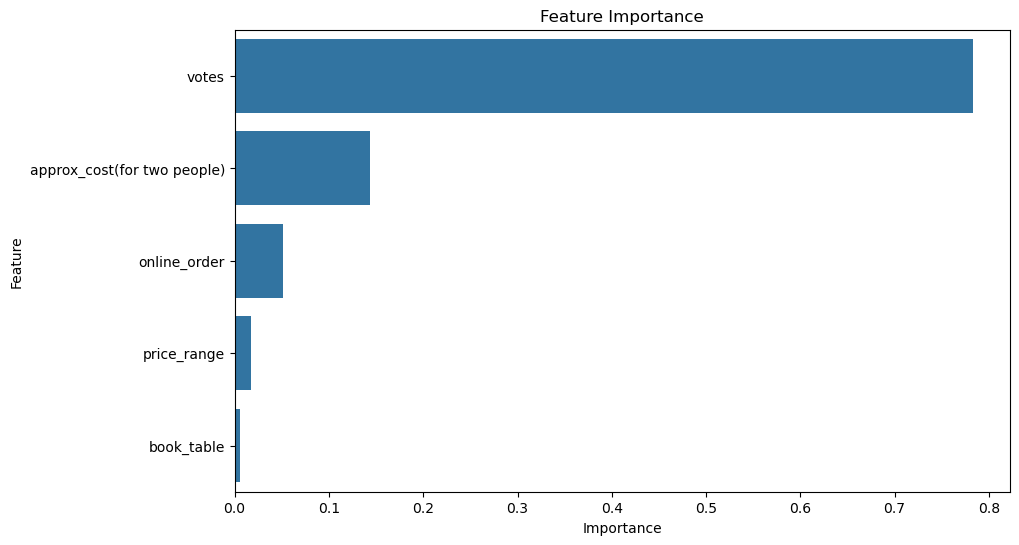

In [5]:
importances = plot_feature_importance(rf_model, X.columns.tolist())

> _**Conclusion**: The Feature Importance plot highlights whether factors like 'votes' (popularity) or 'approx_cost' have the biggest impact on success. This insight is highly valuable for restaurant owners looking to improve their rating._